In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import time
import random
import re

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Check if torch will use Apple Silicon GPU

if torch.backends.mps.is_available():
    mps_device = torch.device("mps")
    x = torch.ones(1, device=mps_device)
    print (x)
else:
    print ("MPS device not found.")

tensor([1.], device='mps:0')


In [3]:
movielens_data_dir = "ml-32m"

In [4]:
num_ratings_to_read = 35_000_000

df_ratings = pd.read_csv(movielens_data_dir + '/ratings.csv', nrows=num_ratings_to_read)

In [5]:
len(df_ratings)

33832162

In [6]:
# clean the ratings data
df_ratings = df_ratings.dropna()
df_ratings['movieId'] = df_ratings['movieId'].astype(int, copy=False)

In [7]:
df_ratings.head(5)

,userId,movieId,rating,timestamp
0,1,1,4.0,1225734739
1,1,110,4.0,1225865086
2,1,158,4.0,1225733503
3,1,260,4.5,1225735204
4,1,356,5.0,1225735119


In [8]:
df_movies = pd.read_csv(movielens_data_dir + '/movies.csv')

In [9]:
df_movies.head(3)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


In [10]:
df_tags = pd.read_csv(movielens_data_dir + '/tags.csv')

In [11]:
df_tags.head(3)

,userId,movieId,tag,timestamp
0,10,260,good vs evil,1430666558
1,10,260,Harrison Ford,1430666505
2,10,260,sci-fi,1430666538


In [12]:
df_tags['tag'] = df_tags['tag'].str.lower()
df_tags['tag'] = df_tags['tag'].str.strip()

In [13]:
counts = df_tags.groupby('tag').size().reset_index(name='count')
df_tags_sorted_counts = counts.sort_values(by='count', ascending=False)

MIN_NUM_TAGS = 1000
df_tags_final_counts = df_tags_sorted_counts[df_tags_sorted_counts['count'] > MIN_NUM_TAGS]  
df_tags_final_counts.head(3)

,tag,count
110730,sci-fi,14917
8556,atmospheric,12776
2299,action,11754


In [14]:
# Get the final tags we want to use as movie features
final_movie_tags = set(df_tags_final_counts['tag'].tolist())
len(final_movie_tags)

306

In [15]:
df_genome_tags = pd.read_csv(movielens_data_dir + '/genome-tags.csv')

In [16]:
df_genome_tags.head(3)

,tagId,tag
0,1,007
1,2,007 (series)
2,3,18th century


In [17]:
genome_tag_id_to_tag_name = dict(zip(df_genome_tags['tagId'], df_genome_tags['tag']))   

In [18]:
df_genome_scores = pd.read_csv(movielens_data_dir + '/genome-scores.csv')

In [19]:
df_genome_scores.head(3)

,movieId,tagId,relevance
0,1,1,0.03200
1,1,2,0.02225
2,1,3,0.07000


In [20]:
# Get the final tags we want to use as movie features (use all for now)
final_movie_genome_tags = set(df_genome_tags['tagId'].tolist())
len(final_movie_genome_tags)

1128

# Movie Feature Processing

In [84]:
# let's only work with movies with enough ratings.

min_ratings_per_movie = 1_000

# get the number of ratings per movie
df_movies_to_num_ratings = df_ratings.groupby('movieId', as_index=False)['rating'].count()
print("total movies in corpus: ", len(df_movies_to_num_ratings))

df_movies_to_num_ratings = df_movies_to_num_ratings.sort_values(by=['rating'], ascending=False)
df_movies_to_num_ratings = df_movies_to_num_ratings[df_movies_to_num_ratings['rating'] > min_ratings_per_movie]
print("movies with enough ratings: ", len(df_movies_to_num_ratings))

# get list of the top movies by number of ratings.
top_movies = df_movies_to_num_ratings.movieId.tolist()

total movies in corpus:  83239
movies with enough ratings:  4461


In [85]:
# keep a map of movieId to number of ratings.
movieId_to_num_ratings = {}
movieId_list = df_movies_to_num_ratings.movieId.tolist()
rating_list = df_movies_to_num_ratings.rating.tolist()
for i in range(len(movieId_list)):
  movieId_to_num_ratings[movieId_list[i]] = rating_list[i]

In [86]:
# map movieId to title
movieId_to_title = {}
title_to_movieId = {}

# map moveiId to year
movieId_to_year = {}

movieId_list = df_movies.movieId.tolist()
title_list = df_movies.title.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  title = title_list[i]

  movieId_to_title[movieId] = title
  title_to_movieId[title] = movieId

  match = re.search(r"\(\d+\)\s*$", title)
  if match:
    year = title[match.start()+1:match.end()-1]
    movieId_to_year[movieId] = year
  else:
    movieId_to_year[movieId] = -1

In [87]:
# keep track of the number of unique year values we see in movieId_to_year
year_to_num_movies = {}
for movieId,year in movieId_to_year.items():
  if year not in year_to_num_movies:
    year_to_num_movies[year] = 0
  year_to_num_movies[year] += 1

In [88]:
# print the top movies
for movieId in top_movies[0:10]:
  print(movieId, movieId_to_title[movieId], movieId_to_num_ratings[movieId])

318 Shawshank Redemption, The (1994) 122296
356 Forrest Gump (1994) 113581
296 Pulp Fiction (1994) 108756
2571 Matrix, The (1999) 107056
593 Silence of the Lambs, The (1991) 101802
260 Star Wars: Episode IV - A New Hope (1977) 97202
2959 Fight Club (1999) 86207
527 Schindler's List (1993) 84232
480 Jurassic Park (1993) 83026
1196 Star Wars: Episode V - The Empire Strikes Back (1980) 80200


In [89]:
# map movieId to list of genres for that movie
genres = set()
movieId_to_genres = {}

movieId_list = df_movies.movieId.tolist()
genre_list = df_movies.genres.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  if movieId not in top_movies:
    continue

  movieId_to_genres[movieId] = set()

  for genre in genre_list[i].split('|'):
    genres.add(genre)
    movieId_to_genres[movieId].add(genre)

In [90]:
movieId_to_genres[title_to_movieId['Matrix, The (1999)']]

{'Action', 'Sci-Fi', 'Thriller'}

In [91]:
# map movieId to the counts of tags for that movie
movieId_to_tag_to_count = {}

movieId_list = df_tags.movieId.tolist()
tag_list = df_tags.tag.tolist()

for i in range(len(movieId_list)):
  movieId = movieId_list[i]
  if movieId not in top_movies:
    continue
      
  if movieId not in movieId_to_tag_to_count:
    movieId_to_tag_to_count[movieId] = {}

  tag = tag_list[i]
  if tag not in final_movie_tags:
    continue
  if tag not in movieId_to_tag_to_count[movieId]:
    movieId_to_tag_to_count[movieId][tag] = 0

  movieId_to_tag_to_count[movieId][tag] += 1

In [92]:
# movieId_to_tag_to_count[title_to_movieId['Matrix, The (1999)']]

In [93]:
# map movieId to the genome tag scores for that movie.
top_movies_set = set(top_movies)                                                                                                                                      
df_top = df_genome_scores[df_genome_scores['movieId'].isin(top_movies_set)]
                                                                                                                                                                        
movieId_to_genome_tag_to_score = {
  mid: dict(zip(grp['tagId'], grp['relevance']))                                                                                                                    
  for mid, grp in df_top.groupby('movieId')
}   

In [94]:
# look at the tags for movies to sanity check them
for tagId, score in movieId_to_genome_tag_to_score[title_to_movieId['Toy Story (1995)']].items():
    print(genome_tag_id_to_tag_name[tagId], score)

007 0.0319999999999999
007 (series) 0.0222499999999999
18th century 0.07
1920s 0.059
1930s 0.123
1950s 0.131
1960s 0.06175
1970s 0.1955
1980s 0.26625
19th century 0.0329999999999999
3d 0.568
70mm 0.137
80s 0.249
9/11 0.0065
aardman 0.0217499999999999
aardman studios 0.17975
abortion 0.014
absurd 0.0757499999999999
action 0.65925
action packed 0.3025
adaptation 0.2985
adapted from:book 0.26775
adapted from:comic 0.0489999999999999
adapted from:game 0.0152499999999999
addiction 0.078
adolescence 0.0752499999999999
adoption 0.23375
adultery 0.0722499999999999
adventure 0.8947499999999999
affectionate 0.6765
afi 100 0.03575
afi 100 (laughs) 0.151
afi 100 (movie quotes) 0.3462499999999999
africa 0.04975
afterlife 0.03625
aging 0.1619999999999999
aids 0.1044999999999999
airplane 0.0115
airport 0.017
alaska 0.0115
alcatraz 0.0135
alcoholism 0.03325
alien 0.3067499999999999
alien invasion 0.0197499999999999
aliens 0.30025
allegory 0.18125
almodovar 0.0087499999999999
alone in the world 0.1415


In [95]:
# for every movie, get the avg rating
df_movies_to_avg_rating = df_ratings.groupby('movieId', as_index=False)['rating'].mean()

movieId_to_avg_rating = {}

movieId_list = df_movies_to_avg_rating.movieId.tolist()
rating_list = df_movies_to_avg_rating.rating.tolist()
for i in range(len(movieId_list)):
  if movieId_list[i] not in top_movies: continue
  movieId_to_avg_rating[movieId_list[i]] = rating_list[i]

In [96]:
# build ITEM movieId embedding mapping
item_emb_movieId_to_i = {s:i for i,s in enumerate(top_movies)}
item_emb_i_to_movieId = {i:s for s,i in item_emb_movieId_to_i.items()}

In [97]:
# build ITEM genre feature context
genre_to_i = {s:i for i,s in enumerate(genres)}
i_to_genre = {i:s for s,i in genre_to_i.items()}

In [98]:
# build ITEM year embedding mapping
year_to_i = {s:i for i,s in enumerate(year_to_num_movies.keys())}
i_to_year = {i:s for s,i in year_to_i.items()}

In [99]:
# build ITEM tag feature context
tag_to_i = {s:i for i,s in enumerate(final_movie_tags)}
i_to_tag = {i:s for s,i in tag_to_i.items()}

In [100]:
# build ITEM genome-tag feature context
genome_tag_to_i = {s:i for i,s in enumerate(final_movie_genome_tags)}
i_to_genome_tag = {i:s for s,i in genome_tag_to_i.items()}

# User Feature Processing

In [101]:
# user_context_movies is no longer needed.
# The user's watch history is now represented as avg pooling over shared item embeddings.
# This saves substantial memory as we no longer need a multi-hot vector per training example.


In [102]:
df_ratings_final = df_ratings[df_ratings.movieId.isin(top_movies)]
df_ratings_final = df_ratings_final.sort_values(['userId', 'timestamp'], ascending=[True, True])

In [103]:
df_ratings_final.head(3)

,userId,movieId,rating,timestamp
2,1,158,4.0,1225733503
37,1,4896,4.0,1225733516
6,1,596,4.0,1225733524


In [104]:
# aggregate dataframe down into one row per user and list of their movies and ratings.
df_ratings_final = df_ratings_final.groupby('userId').agg(
    {'movieId': lambda x: list(x),
     'rating': lambda y: list(y),
     'timestamp': lambda z: list(z)
    }).reset_index()

In [105]:
df_ratings_final.head(3)

,userId,movieId,rating,timestamp
0,1,"[158, 4896, 596, 1396, 1376, 1909, 2336, 1293,...","[4.0, 4.0, 4.0, 3.0, 3.0, 3.0, 3.5, 2.0, 3.0, ...","[1225733503, 1225733516, 1225733524, 122573353..."
1,2,"[592, 590, 150, 296, 380, 165, 349, 588, 153, ...","[3.0, 5.0, 5.0, 5.0, 4.0, 4.0, 4.0, 4.0, 3.0, ...","[835815551, 835815552, 835815553, 835815554, 8..."
2,3,"[2959, 318, 79132, 858, 177765, 296, 116797, 9...","[5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, 5.0, ...","[1536173840, 1536173843, 1536173845, 153617384..."


In [106]:
# The user context contains two halves:
#   First half  (indices 0 .. len(genres)-1)          : per-genre avg rating (debiased)
#   Second half (indices len(genres) .. 2*len(genres)-1): per-genre watch count fraction
# The watch history (movie IDs) is stored separately and handled via avg pooling in the model.
user_context_size = len(genres) * 2

user_context_genre_avg_rating_to_i  = {s: i             for i, s in enumerate(list(genres))}
user_context_i_to_genre_avg_rating  = {i: s             for s, i in user_context_genre_avg_rating_to_i.items()}

user_context_genre_watch_count_to_i = {s: len(genres) + i for i, s in enumerate(list(genres))}
user_context_i_to_genre_watch_count = {i: s             for s, i in user_context_genre_watch_count_to_i.items()}


# Generate Training Examples

In [107]:
# simulate training examples by masking out some of the user's watched movies from their context, and using them as labels.
# we do not want the 'movie to predict' in their watch history, as we are trying to simulate the following:
# given the user's watch history, what would they rate this new movie?
# NOTE: this is not the same as a train/test split. This is just simulating how training examples would look like on a movie platform.

percent_ratings_as_watch_history = 0.9

min_ratings_per_user = 20 # ignore users with too few movie watches
max_ratings_per_user = 500 # ignore users with way too many movie watches
too_few_ratings = 0
too_many_ratings = 0

user_to_movie_to_rating_WATCH_HISTORY = {}
user_to_movie_to_rating_LABEL = {}
user_to_movie_to_timestamp_LABEL = {}

# loop over each column as this is much, much faster than going row by row.
user_list = df_ratings_final['userId'].tolist()
movieId_list_list = df_ratings_final['movieId'].tolist()
rating_list_list = df_ratings_final['rating'].tolist()
timestamp_list_list = df_ratings_final['timestamp'].tolist()

for i in range(len(user_list)):
  userId = user_list[i]
  movieId_list = movieId_list_list[i]
  rating_list = rating_list_list[i]
  timestamp_list = timestamp_list_list[i]

  num_rated_movies = len(movieId_list)

  # ignore users with too few or too many ratings.
  if num_rated_movies < min_ratings_per_user:
    too_few_ratings += 1
    continue
  if num_rated_movies > max_ratings_per_user:
    too_many_ratings += 1
    continue

  # set up training example maps.
  user_to_movie_to_rating_WATCH_HISTORY[userId] = {}
  user_to_movie_to_rating_LABEL[userId] = {}
  user_to_movie_to_timestamp_LABEL[userId] = {}

  # put earlier watched movies into user's watch history (features) and leave later watched movies as labels to predict.
  rated_movies = list(zip(movieId_list, rating_list, timestamp_list))
  for movieId,rating,timestamp in rated_movies[:int(num_rated_movies * percent_ratings_as_watch_history)]:
    user_to_movie_to_rating_WATCH_HISTORY[userId][movieId] = rating
  for movieId,rating,timestamp in rated_movies[int(num_rated_movies * percent_ratings_as_watch_history):]:
    user_to_movie_to_rating_LABEL[userId][movieId] = rating
    user_to_movie_to_timestamp_LABEL[userId][movieId] = timestamp

In [108]:
len(user_list), len(user_to_movie_to_rating_WATCH_HISTORY.keys()), too_few_ratings, too_many_ratings

(330136, 190670, 128829, 10637)

In [109]:
# for every user, get their avg rating.
# this will help us debias each user's rating.
user_to_avg_rating = {}

# NOTE: only use ratings from their synthetic watch history.
for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
  user_to_avg_rating[user] = 0
  for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys():
    user_to_avg_rating[user] += user_to_movie_to_rating_WATCH_HISTORY[user][movieId]

  user_to_avg_rating[user] /= len(user_to_movie_to_rating_WATCH_HISTORY[user].keys())

In [110]:
user_to_avg_rating[1]

3.9722222222222223

In [111]:
# for every user, get the avg rating for every genre
user_to_genre_to_stat = {}

# NOTE: only use ratings from their synthetic watch history.
for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
  user_to_genre_to_stat[user] = {}
  for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys():
    for genre in movieId_to_genres[movieId]:
      if genre not in user_to_genre_to_stat[user]:
        user_to_genre_to_stat[user][genre] = {
            'NUM_RATINGS': 0,
            'SUM_RATINGS': 0,
        }

      user_to_genre_to_stat[user][genre]['NUM_RATINGS'] += 1
      user_to_genre_to_stat[user][genre]['SUM_RATINGS'] += user_to_movie_to_rating_WATCH_HISTORY[user][movieId]

for user in user_to_genre_to_stat.keys():
  for genre in user_to_genre_to_stat[user].keys():
    num_ratings = user_to_genre_to_stat[user][genre]['NUM_RATINGS']
    sum_ratings = user_to_genre_to_stat[user][genre]['SUM_RATINGS']
    user_to_genre_to_stat[user][genre]['AVG_RATING'] = sum_ratings / num_ratings


In [112]:
# Build per-user genre context and watch history.
#
# user_to_context:       [avg_rating_per_genre | watch_count_fraction_per_genre] — shape (2*len(genres),) per user
# user_to_watch_history: list of emb_idx for the most recent N watched movies

MAX_HISTORY_LEN = 50  # cap to most recent N movies; older watches add little signal via avg pool

user_to_context = {}
user_to_watch_history = {}
user_to_watch_history_ratings = {}  # parallel to user_to_watch_history: debiased rating per movie

for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
    context = [0.0] * user_context_size
    total_watches = len(user_to_movie_to_rating_WATCH_HISTORY[user])

    for genre in user_to_genre_to_stat[user].keys():
        # First half: debiased avg rating per genre
        context[user_context_genre_avg_rating_to_i[genre]] = float(
            user_to_genre_to_stat[user][genre]['AVG_RATING'] - user_to_avg_rating[user]
        )
        # Second half: fraction of total watches in this genre
        context[user_context_genre_watch_count_to_i[genre]] = float(
            user_to_genre_to_stat[user][genre]['NUM_RATINGS'] / total_watches
        )
    user_to_context[user] = context

    # Watch history: embedding indices + debiased ratings, capped to most recent N.
    # Ratings are debiased (rating - user_mean) so the scale matches the training labels.
    watch_history_with_ratings = [
        (item_emb_movieId_to_i[movieId],
         user_to_movie_to_rating_WATCH_HISTORY[user][movieId] - user_to_avg_rating[user])
        for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys()
        if movieId in item_emb_movieId_to_i
    ][-MAX_HISTORY_LEN:]
    user_to_watch_history[user]         = [x[0] for x in watch_history_with_ratings]
    user_to_watch_history_ratings[user] = [x[1] for x in watch_history_with_ratings]


In [113]:
# for every movie, create a training example feature GENRE context vector lookup
# it will contain the movie's genres.
movieId_to_genre_context = {}
for movieId in top_movies:
  genre_context = [0.0] * len(genres)

  for genre in movieId_to_genres[movieId]:
    genre_context[genre_to_i[genre]] = float(1.0)

  movieId_to_genre_context[movieId] = genre_context

In [114]:
# for every movie, create a training example feature TAG context vector lookup.
# Tag values are normalized: each value is that tag's count divided by the sum of all tag counts
# for that movie, making the vector a probability distribution over tags.
# Movies with zero total tag count get an all-zero vector.
movieId_to_tag_context = {}
for movieId in top_movies:
    tag_context = [0.0] * len(final_movie_tags)

    total_count = sum(count for tag, count in movieId_to_tag_to_count[movieId].items())
    if total_count > 0:
        for tag, count in movieId_to_tag_to_count[movieId].items():
            tag_context[tag_to_i[tag]] = float(count) / total_count

    movieId_to_tag_context[movieId] = tag_context

In [115]:
# Build per-user tag profile: unweighted average of normalized tag vectors across watch history.
# Mirrors the avg-pool approach used for movie embeddings in the user history tower.

tag_matrix = np.array([movieId_to_tag_context[movieId] for movieId in top_movies], dtype=np.float32)
movieId_to_row = {movieId: i for i, movieId in enumerate(top_movies)}

user_to_tag_context = {}
for user in user_to_movie_to_rating_WATCH_HISTORY.keys():
    rows = [
        movieId_to_row[movieId]
        for movieId in user_to_movie_to_rating_WATCH_HISTORY[user].keys()
        if movieId in movieId_to_row
    ]
    if rows:
        user_to_tag_context[user] = tag_matrix[rows].mean(axis=0).tolist()
    else:
        user_to_tag_context[user] = [0.0] * len(final_movie_tags)

In [116]:
# for every movie, create a training example feature GENOME-TAG context vector lookup
# it will contain the movie's genome tags.
# Movies that are not in movieId_to_genome_tag_to_score will have all-zero vector.

# <double_check>
movieId_to_genome_tag_context = {}
for movieId in top_movies:
    genome_tag_context = [0.0] * len(final_movie_genome_tags)

    for genome_tag, score in movieId_to_genome_tag_to_score[movieId].items():
        genome_tag_context[genome_tag_to_i[genome_tag]] = score

    movieId_to_genome_tag_context[movieId] = genome_tag_context
# </double_check>

# Build Datasets

In [117]:
# Prepare the buckets for our timestamps so we can use them as categorical features
timestamp_num_bins = 1500
timestamp_bins = torch.tensor(np.linspace(df_ratings['timestamp'].min(), df_ratings['timestamp'].max(), timestamp_num_bins))

In [118]:
# PAD_IDX is one beyond the last valid movie index (0..top_movies_len-1).
# The Embedding layer's padding_idx=PAD_IDX will zero-out those positions automatically.
PAD_IDX = len(top_movies)

def pad_history_batch(histories):
    """Pad variable-length watch histories to the batch max length.
    Returns a (batch, max_hist_len) long tensor. Padded positions are PAD_IDX.
    """
    max_len = max((len(h) for h in histories), default=1)
    padded = torch.full((len(histories), max_len), PAD_IDX, dtype=torch.long)
    for i, hist in enumerate(histories):
        if len(hist) > 0:
            padded[i, :len(hist)] = torch.tensor(hist, dtype=torch.long)
    return padded

def pad_history_ratings_batch(history_ratings):
    """Pad variable-length watch history rating sequences to the batch max length.
    Returns a (batch, max_hist_len) float tensor. Padded positions are 0.0.
    """
    max_len = max((len(r) for r in history_ratings), default=1)
    padded = torch.zeros(len(history_ratings), max_len)
    for i, ratings in enumerate(history_ratings):
        if len(ratings) > 0:
            padded[i, :len(ratings)] = torch.tensor(ratings, dtype=torch.float)
    return padded

def build_dataset(users):
    X = []
    X_history = []          # list of emb_idx lists (variable length per user)
    X_history_ratings = []  # list of debiased-rating lists, parallel to X_history
    X_tag = []              # user tag profile: avg of watched movies' tag vectors
    timestamp = []
    target_movieId = []
    target_movieId_genre_context = []
    target_movieId_tag_context = []
    target_movieId_genome_tag_context = []
    target_movieId_year = []
    Y = []

    for user in users:
        for movieId in user_to_movie_to_rating_LABEL[user].keys():
            X.append(user_to_context[user])
            X_history.append(user_to_watch_history[user])
            X_history_ratings.append(user_to_watch_history_ratings[user])
            X_tag.append(user_to_tag_context[user])
            timestamp.append(user_to_movie_to_timestamp_LABEL[user][movieId])
            target_movieId.append(item_emb_movieId_to_i[movieId])
            target_movieId_genre_context.append(movieId_to_genre_context[movieId])
            target_movieId_tag_context.append(movieId_to_tag_context[movieId])
            target_movieId_genome_tag_context.append(movieId_to_genome_tag_context[movieId])
            target_movieId_year.append(year_to_i[movieId_to_year[movieId]])
            Y.append(float(user_to_movie_to_rating_LABEL[user][movieId] - user_to_avg_rating[user]))

    X = torch.tensor(X)
    X_tag = torch.tensor(X_tag)
    Y = torch.tensor(Y)
    target_movieId = torch.tensor(target_movieId)
    target_movieId_genre_context = torch.tensor(target_movieId_genre_context)
    target_movieId_tag_context = torch.tensor(target_movieId_tag_context)
    target_movieId_genome_tag_context = torch.tensor(target_movieId_genome_tag_context)
    target_movieId_year = torch.tensor(target_movieId_year)
    timestamp = torch.bucketize(torch.tensor(timestamp), timestamp_bins, right=False)

    return X, X_history, X_history_ratings, X_tag, timestamp, Y, target_movieId, target_movieId_genre_context, target_movieId_tag_context, target_movieId_genome_tag_context, target_movieId_year


In [119]:
# user users with enough ratings to predict to be useful for model learning.
final_users = []
skipped_users = 0

for user in user_to_movie_to_rating_LABEL.keys():
  num_ratings = len(user_to_movie_to_rating_LABEL[user])

  # having at least 2 watched movies in the user's LABEL split means they have watched at least 20 movies
  # 18 of these movies are used for the user's watch history
  if num_ratings >= 2 and num_ratings < 500:
    final_users.append(user)
  else:
    skipped_users +=1 

print('final users', len(final_users))
print('skipped users', skipped_users)

final users 190670
skipped users 0


In [120]:
# split users into train and validation users
percent_users_train = 0.9

random.shuffle(final_users)

train_users = final_users[:int(len(final_users) * percent_users_train)]
validation_users = final_users[int(len(final_users) * percent_users_train):]

In [121]:
X_train, X_history_train, X_history_ratings_train, X_tag_train, timestamp_train, Y_train, target_movieId_train, target_movieId_genre_context_train, target_movieId_tag_context_train, target_movieId_genome_tag_context_train, target_movieId_year_train = build_dataset(train_users)
X_val,   X_history_val,   X_history_ratings_val,   X_tag_val,   timestamp_val,   Y_val,   target_movieId_val,   target_movieId_genre_context_val,   target_movieId_tag_context_val,   target_movieId_genome_tag_context_val,   target_movieId_year_val   = build_dataset(validation_users)


In [122]:
print("train:")
print("  X_train (genre context):                 ", X_train.shape)
print("  X_history_train (list of lists):         ", f"{len(X_history_train)} examples, variable-length histories")
print("  X_tag_train (user tag profile):          ", X_tag_train.shape)
print("  timestamp_train:                         ", timestamp_train.shape)
print("  Y_train:                                 ", Y_train.shape)
print("  target_movieId_train:                    ", target_movieId_train.shape)
print("  target_movieId_genre_context_train:      ", target_movieId_genre_context_train.shape)
print("  target_movieId_tag_context_train:        ", target_movieId_tag_context_train.shape)
print("  target_movieId_genome_tag_context_train: ", target_movieId_genome_tag_context_train.shape)
print("  target_movieId_year_train:               ", target_movieId_year_train.shape)
print()
print("val:")
print("  X_val (genre context):                   ", X_val.shape)
print("  X_history_val (list of lists):           ", f"{len(X_history_val)} examples, variable-length histories")
print("  X_tag_val (user tag profile):            ", X_tag_val.shape)
hist_lens = [len(h) for h in X_history_train]
print(f"  history length stats — min: {min(hist_lens)}  max: {max(hist_lens)}  mean: {sum(hist_lens)/len(hist_lens):.1f}")


train:
  X_train (genre context):                  torch.Size([1898990, 40])
  X_history_train (list of lists):          1898990 examples, variable-length histories
  X_tag_train (user tag profile):           torch.Size([1898990, 306])
  timestamp_train:                          torch.Size([1898990])
  Y_train:                                  torch.Size([1898990])
  target_movieId_train:                     torch.Size([1898990])
  target_movieId_genre_context_train:       torch.Size([1898990, 20])
  target_movieId_tag_context_train:         torch.Size([1898990, 306])
  target_movieId_genome_tag_context_train:  torch.Size([1898990, 1128])
  target_movieId_year_train:                torch.Size([1898990])

val:
  X_val (genre context):                    torch.Size([209721, 40])
  X_history_val (list of lists):            209721 examples, variable-length histories
  X_tag_val (user tag profile):             torch.Size([209721, 306])
  history length stats — min: 18  max: 50  mean: 47.4


# Build our Two Tower Model

In [123]:
'''
User side:
  avg_pool(item_emb[watched_movies])  --> history_emb (item_movieId_embedding_size)
                                              \
  [avg_rating | watch_count_frac]              \
  per genre --> user_genre_tower --> genre_emb  \
                                                 --> cat --> user_combined
  avg(tag_vecs[watched_movies])                /
  --> user_tag_tower --> tag_emb  [optional]  /
                                             /
  timestamp_emb --> ts_tower --> ts_emb    /

Item side:
  movie_genres       --> genre_tower                    \
  movie_tags         --> tag_tower          [optional]   \
  movie_genome_tags  --> genome_tag_tower   [optional]    \
                                                           --> cat --> item_combined
  movie_id_emb       --> item_tower                      /
  movie_year         --> year_tower                     /

Prediction: dot_product(user_combined, item_combined)

Dimension constraint:
  user: history(item_movieId_embedding_size) + user_genre + ts(timestamp_feature_embedding_size) + user_tag*
  item: item_genre + item_tag* + item_genome_tag** + movieId(item_movieId_embedding_size) + year(item_year_embedding_size)
  (* = 0 when corresponding tower is disabled)
  Both sides must be equal.

  user_genre = 50 - user_tag
  item_genre = 50 - item_tag - item_genome_tag

  Example (user_tag=0, item_tag=20, genome_tag=20):
    user: 40 + 50 + 10 + 0  = 100
    item: 10 + 20 + 20 + 40 + 10 = 100
'''

class MovieRecommender(nn.Module):
    def __init__(self,
                 genres_len,
                 tags_len,
                 genome_tags_len,
                 top_movies_len,
                 all_years_len,
                 timestamp_num_bins,
                 user_context_size,
                 item_genre_embedding_size=10,
                 item_tag_embedding_size=20,
                 item_genome_tag_embedding_size=20,
                 item_movieId_embedding_size=40,
                 item_year_embedding_size=10,
                 user_genre_embedding_size=50,
                 user_tag_embedding_size=0,
                 timestamp_feature_embedding_size=10,
                 use_user_tag_tower=False,
                 use_item_tag_tower=True,
                 use_item_genome_tag_tower=True,
                ):
        """
        Args:
            genres_len (int): Number of unique genres.
            tags_len (int): Number of unique user-applied tags.
            genome_tags_len (int): Number of genome tags.
            top_movies_len (int): Number of movies in the embedding table.
            all_years_len (int): Number of unique release years.
            timestamp_num_bins (int): Number of timestamp buckets.
            user_context_size (int): Size of the user genre context vector (2*genres_len).
            item_genre_embedding_size (int): Output size of the item genre tower.
            item_tag_embedding_size (int): Output size of the item tag tower (ignored when use_item_tag_tower=False).
            item_genome_tag_embedding_size (int): Output size of the genome tag tower (ignored when use_item_genome_tag_tower=False).
            item_movieId_embedding_size (int): Embedding dim for movie IDs.
                Shared between item tower and user history avg pooling.
            item_year_embedding_size (int): Output size of the year tower.
            user_genre_embedding_size (int): Output size of the user genre tower.
            user_tag_embedding_size (int): Output size of the user tag tower (ignored when use_user_tag_tower=False).
            timestamp_feature_embedding_size (int): Embedding dim for timestamps.
            use_user_tag_tower (bool): If True, include the user tag tower in the user embedding.
            use_item_tag_tower (bool): If True, include the item (user-applied) tag tower in the item embedding.
            use_item_genome_tag_tower (bool): If True, include the genome tag tower in the item embedding.

        Dimension constraint:
            user: item_movieId_embedding_size + user_genre_embedding_size
                  + timestamp_feature_embedding_size + (user_tag_embedding_size if use_user_tag_tower else 0)
            item: item_genre_embedding_size + (item_tag_embedding_size if use_item_tag_tower else 0)
                  + (item_genome_tag_embedding_size if use_item_genome_tag_tower else 0)
                  + item_movieId_embedding_size + item_year_embedding_size
            Both must be equal.
        """
        super().__init__()

        self.use_user_tag_tower        = use_user_tag_tower
        self.use_item_tag_tower        = use_item_tag_tower
        self.use_item_genome_tag_tower = use_item_genome_tag_tower

        # PAD index sits one beyond valid indices (0 .. top_movies_len-1)
        self.pad_idx = top_movies_len

        # ── Shared item embedding ─────────────────────────────────────────────
        # Used by BOTH the item tower (target movie) and the user history avg pool.
        self.item_embedding_lookup = nn.Embedding(
            top_movies_len + 1, item_movieId_embedding_size, padding_idx=top_movies_len
        )
        self.item_embedding_tower = nn.Sequential(
            nn.Linear(item_movieId_embedding_size, item_movieId_embedding_size),
            nn.Tanh()
        )

        # ── Item feature towers ───────────────────────────────────────────────
        self.item_genre_tower = nn.Sequential(
            nn.Linear(genres_len, item_genre_embedding_size),
            nn.Tanh()
        )
        if use_item_tag_tower:
            self.item_tag_tower = nn.Sequential(
                nn.Linear(tags_len, item_tag_embedding_size),
                nn.Tanh()
            )
        if use_item_genome_tag_tower:
            self.item_genome_tag_tower = nn.Sequential(
                nn.Linear(genome_tags_len, item_genome_tag_embedding_size),
                nn.Tanh()
            )
        self.year_embedding_lookup = nn.Embedding(all_years_len, item_year_embedding_size)
        self.year_embedding_tower = nn.Sequential(
            nn.Linear(item_year_embedding_size, item_year_embedding_size),
            nn.Tanh()
        )

        # ── User towers ───────────────────────────────────────────────────────
        self.user_genre_tower = nn.Sequential(
            nn.Linear(user_context_size, user_genre_embedding_size),
            nn.Tanh()
        )
        if use_user_tag_tower:
            # Tag profile tower: takes avg of watched movies' tag vectors
            self.user_tag_tower = nn.Sequential(
                nn.Linear(tags_len, user_tag_embedding_size),
                nn.Tanh()
            )
        self.timestamp_embedding_lookup = nn.Embedding(timestamp_num_bins, timestamp_feature_embedding_size)
        self.timestamp_embedding_tower = nn.Sequential(
            nn.Linear(timestamp_feature_embedding_size, timestamp_feature_embedding_size),
            nn.Tanh()
        )

        # ── Dimension check ───────────────────────────────────────────────────
        effective_user_tag    = user_tag_embedding_size        if use_user_tag_tower        else 0
        effective_item_tag    = item_tag_embedding_size        if use_item_tag_tower        else 0
        effective_genome_tag  = item_genome_tag_embedding_size if use_item_genome_tag_tower else 0
        user_side = item_movieId_embedding_size + user_genre_embedding_size + timestamp_feature_embedding_size + effective_user_tag
        item_side = item_genre_embedding_size + effective_item_tag + effective_genome_tag + item_movieId_embedding_size + item_year_embedding_size
        if user_side != item_side:
            raise ValueError(
                f"User embedding size ({user_side} = history {item_movieId_embedding_size} + "
                f"genre {user_genre_embedding_size} + timestamp {timestamp_feature_embedding_size} + "
                f"tag {effective_user_tag}) "
                f"must match item embedding size ({item_side} = genre {item_genre_embedding_size} + "
                f"tag {effective_item_tag} + genome_tag {effective_genome_tag} + "
                f"movieId {item_movieId_embedding_size} + year {item_year_embedding_size}). "
                f"Adjust embedding sizes."
            )

        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.xavier_uniform_(module.weight, gain=0.01)
            if module.bias is not None:
                torch.nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.xavier_uniform_(module.weight, gain=0.01)

    def forward(self, user_genre_contexts, user_tag_contexts, user_watch_history, user_watch_history_ratings, timestamps,
                movie_genres, movie_tags, movie_genome_tags, years, target_movieId):
        """
        Args:
            user_genre_contexts        (Tensor): (batch, user_context_size) — per-genre avg rating + watch count fraction
            user_tag_contexts          (Tensor): (batch, tags_len)          — avg tag vector over watch history (unused when use_user_tag_tower=False)
            user_watch_history         (Tensor): (batch, max_hist_len)      — padded movie ID indices
            user_watch_history_ratings (Tensor): (batch, max_hist_len)      — debiased ratings per history movie; 0 at padding
            timestamps                 (Tensor): (batch,)                   — bucketized timestamp indices
            movie_genres               (Tensor): (batch, genres_len)        — target movie genre features
            movie_tags                 (Tensor): (batch, tags_len)          — target movie user-applied tag features (unused when use_item_tag_tower=False)
            movie_genome_tags          (Tensor): (batch, genome_tags_len)   — target movie genome tag scores (unused when use_item_genome_tag_tower=False)
            years                      (Tensor): (batch,)                   — target movie year indices
            target_movieId             (Tensor): (batch,)                   — target movie ID indices
        """
        # ── User history tower (rating-weighted avg pool over shared item embeddings) ──
        # Each movie embedding is weighted by the user's debiased rating for that movie.
        # Highly-rated movies pull the history embedding toward them more strongly than
        # average-rated ones. Absolute-value normalization prevents low-rated movies
        # (negative debiased ratings) from cancelling out high-rated ones in the denominator.
        history_embs   = self.item_embedding_lookup(user_watch_history)           # (batch, hist_len, emb_dim)
        pad_mask       = (user_watch_history != self.pad_idx).float().unsqueeze(-1)  # (batch, hist_len, 1)
        rating_weights = user_watch_history_ratings.unsqueeze(-1) * pad_mask         # (batch, hist_len, 1)
        weight_sum     = rating_weights.abs().sum(dim=1).clamp(min=1e-6)             # (batch, emb_dim)
        history_emb    = (history_embs * rating_weights).sum(dim=1) / weight_sum     # (batch, emb_dim)

        # ── User genre tower ──────────────────────────────────────────────────
        genre_emb = self.user_genre_tower(user_genre_contexts)              # (batch, user_genre_embedding_size)

        # ── Timestamp tower ───────────────────────────────────────────────────
        ts_emb = self.timestamp_embedding_tower(
            self.timestamp_embedding_lookup(timestamps)
        )                                                                    # (batch, timestamp_feature_embedding_size)

        # ── Combine user side ─────────────────────────────────────────────────
        if self.use_user_tag_tower:
            tag_emb = self.user_tag_tower(user_tag_contexts)                # (batch, user_tag_embedding_size)
            user_combined = torch.cat([history_emb, genre_emb, tag_emb, ts_emb], dim=1)
        else:
            user_combined = torch.cat([history_emb, genre_emb, ts_emb], dim=1)

        # ── Item feature towers ───────────────────────────────────────────────
        item_genre_emb = self.item_genre_tower(movie_genres)
        item_emb       = self.item_embedding_tower(
            self.item_embedding_lookup(target_movieId)
        )
        year_emb       = self.year_embedding_tower(
            self.year_embedding_lookup(years)
        )

        # ── Combine item side ─────────────────────────────────────────────────
        item_parts = [item_genre_emb]
        if self.use_item_tag_tower:
            item_parts.append(self.item_tag_tower(movie_tags))
        if self.use_item_genome_tag_tower:
            item_parts.append(self.item_genome_tag_tower(movie_genome_tags))
        item_parts += [item_emb, year_emb]
        item_combined = torch.cat(item_parts, dim=1)

        # ── Dot product prediction ────────────────────────────────────────────
        preds = torch.einsum('ij, ij -> i', user_combined, item_combined)

        return preds


# Training Loop

In [124]:
# --- Training Loop ---

# Toggle each tag tower independently.
# The genre towers absorb the freed-up dims to keep both sides = 100.
#
#   user side: history(40) + user_genre + ts(10) + user_tag = 100
#   item side: item_genre  + item_tag   + genome_tag + movieId(40) + year(10) = 100
#
#   => user_genre = 50 - user_tag
#   => item_genre = 50 - item_tag - genome_tag
#
# Valid combinations (with item_tag=20, genome_tag=20 defaults):
#   user_tag  item_tag  genome_tag  user_genre  item_genre  | user  item
#   --------  --------  ----------  ----------  ----------  | ----  ----
#     20        10        30           30           10      |  100   100  (all on)
#      0        10        30           50           10      |  100   100  (user tag off)
#     20         0        30           30           20      |  100   100  (item tag off)
#      0         0        30           50           20      |  100   100  (user+item tag off)
#     20        10         0           30           40      |  100   100  (genome off)
#      0        10         0           50           40      |  100   100  (user tag + genome off)
#     20         0         0           30           50      |  100   100  (both item tags off)
#      0         0         0           50           50      |  100   100  (all off)
USE_USER_TAG_TOWER        = False
USE_ITEM_TAG_TOWER        = True
USE_ITEM_GENOME_TAG_TOWER = True

# Fixed dims (do not change)
item_movieId_embedding_size      = 40
item_year_embedding_size         = 10
timestamp_feature_embedding_size = 10

# Tag embedding sizes (0 when tower is disabled).
# Adjust sizes to taste; item_genre absorbs all freed dims automatically.
user_tag_embedding_size        = 20 if USE_USER_TAG_TOWER        else 0
item_tag_embedding_size        = 15 if USE_ITEM_TAG_TOWER        else 0
item_genome_tag_embedding_size = 25 if USE_ITEM_GENOME_TAG_TOWER else 0

# Genre towers absorb freed dims so both sides stay = 100
user_genre_embedding_size = 50 - user_tag_embedding_size
item_genre_embedding_size = 50 - item_tag_embedding_size - item_genome_tag_embedding_size

# Instantiate the MovieRecommender model
model = MovieRecommender(
    genres_len=len(genres),
    tags_len=len(final_movie_tags),
    genome_tags_len=len(final_movie_genome_tags),
    top_movies_len=len(top_movies),
    all_years_len=len(year_to_num_movies),
    timestamp_num_bins=timestamp_num_bins,
    user_context_size=user_context_size,
    item_genre_embedding_size=item_genre_embedding_size,
    item_tag_embedding_size=item_tag_embedding_size,
    item_genome_tag_embedding_size=item_genome_tag_embedding_size,
    item_movieId_embedding_size=item_movieId_embedding_size,
    item_year_embedding_size=item_year_embedding_size,
    user_genre_embedding_size=user_genre_embedding_size,
    user_tag_embedding_size=user_tag_embedding_size,
    timestamp_feature_embedding_size=timestamp_feature_embedding_size,
    use_user_tag_tower=USE_USER_TAG_TOWER,
    use_item_tag_tower=USE_ITEM_TAG_TOWER,
    use_item_genome_tag_tower=USE_ITEM_GENOME_TAG_TOWER,
)

# Print the total number of trainable parameters in the model
print(f"Number of trainable parameters: {sum(p.nelement() for p in model.parameters() if p.requires_grad)}")


Number of trainable parameters: 232350


In [125]:
USE_GPU = False

if USE_GPU:
    mps_device = torch.device("mps")
    
    # Move the model to the GPU
    model.to(mps_device)
    
    # move validation data to MPS
    X_val = X_val.to(mps_device)
    timestamp_val = timestamp_val.to(mps_device)
    target_movieId_genre_context_val = target_movieId_genre_context_val.to(mps_device)
    target_movieId_tag_context_val = target_movieId_tag_context_val.to(mps_device)
    target_movieId_genome_tag_context_val = target_movieId_genome_tag_context_val.to(mps_device)
    target_movieId_year_val = target_movieId_year_val.to(mps_device)
    target_movieId_val = target_movieId_val.to(mps_device)
    Y_val = Y_val.to(mps_device)
    
    # move training data to MPS
    X_train = X_train.to(mps_device)
    timestamp_train = timestamp_train.to(mps_device)
    target_movieId_genre_context_train = target_movieId_genre_context_train.to(mps_device)
    target_movieId_tag_context_train = target_movieId_tag_context_train.to(mps_device)
    target_movieId_genome_tag_context_train = target_movieId_genome_tag_context_train.to(mps_device)
    target_movieId_year_train = target_movieId_year_train.to(mps_device)
    target_movieId_train = target_movieId_train.to(mps_device)
    Y_train = Y_train.to(mps_device)
else:
    # move validation data to CPU
    X_val = X_val.cpu()
    timestamp_val = timestamp_val.cpu()
    target_movieId_genre_context_val = target_movieId_genre_context_val.cpu()
    target_movieId_tag_context_val = target_movieId_tag_context_val.cpu()
    target_movieId_genome_tag_context_val = target_movieId_genome_tag_context_val.cpu()
    target_movieId_year_val = target_movieId_year_val.cpu()
    target_movieId_val = target_movieId_val.cpu()
    Y_val = Y_val.cpu()
    
    # move training data to CPU
    X_train = X_train.cpu()
    timestamp_train = timestamp_train.cpu()
    target_movieId_genre_context_train = target_movieId_genre_context_train.cpu()
    target_movieId_tag_context_train = target_movieId_tag_context_train.cpu()
    target_movieId_genome_tag_context_train = target_movieId_genome_tag_context_train.cpu()
    target_movieId_year_train = target_movieId_year_train.cpu()
    target_movieId_train = target_movieId_train.cpu()
    Y_train = Y_train.cpu()

In [126]:
# Set the loss function (Mean Squared Error Loss for regression)
loss_fn = torch.nn.MSELoss()

# Set the optimizer (Stochastic Gradient Descent)
# It will manage the updates to all parameters in `model.parameters()`
optimizer = torch.optim.SGD(model.parameters(), lr=0.005, momentum=0.9)

# Training configuration
minibatch_size = 64
loss_train = [] # To store training loss for each step
loss_val = []   # To store validation loss for full validation runs

log_every = 10_000      # How often to perform a full validation run and log
training_steps = 150_000 # Total training iterations

# Checkpointing
# - best_val checkpoint: saved whenever val loss improves; always reflects the best model seen so far
# - periodic checkpoint: saved every `checkpoint_every` steps regardless of val loss;
#   useful for going back to an earlier point if the best checkpoint turns out to be overfit
checkpoint_every = 30_000
checkpoint_dir   = 'saved_models'

In [127]:
import os
from datetime import datetime

print("\nStarting training loop...")

# Timestamp generated once at the start of each run; used as a prefix for all checkpoint
# filenames so that best + periodic checkpoints from the same run share a common identifier
run_timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Tracks the lowest val loss seen so far; used to decide whether to save a new best checkpoint
best_val_loss = float('inf')

start = time.time()
for i in range(training_steps):
    is_full_val_run = False
    if i % log_every == 0:
        is_full_val_run = True

    if is_full_val_run:
        user_genre_contexts_batch        = X_val
        user_tag_contexts_batch          = X_tag_val
        user_watch_history_batch         = pad_history_batch(X_history_val)
        user_watch_history_ratings_batch = pad_history_ratings_batch(X_history_ratings_val)
        timestamps_batch                 = timestamp_val
        movie_genres_batch               = target_movieId_genre_context_val
        movie_tags_batch                 = target_movieId_tag_context_val
        movie_genome_tags_batch          = target_movieId_genome_tag_context_val
        movie_years_batch                = target_movieId_year_val
        target_movieId_batch             = target_movieId_val
        Y_batch                          = Y_val

        model.eval()
        with torch.no_grad():
            preds = model(user_genre_contexts_batch, user_tag_contexts_batch, user_watch_history_batch, user_watch_history_ratings_batch, timestamps_batch,
                          movie_genres_batch, movie_tags_batch, movie_genome_tags_batch, movie_years_batch, target_movieId_batch)
            output = loss_fn(preds, Y_batch)

        loss_val.append(output.item())
    else:
        ix = torch.randint(0, X_train.shape[0], (minibatch_size,)).tolist()
        user_genre_contexts_batch        = X_train[ix]
        user_tag_contexts_batch          = X_tag_train[ix]
        user_watch_history_batch         = pad_history_batch([X_history_train[j] for j in ix])
        user_watch_history_ratings_batch = pad_history_ratings_batch([X_history_ratings_train[j] for j in ix])
        timestamps_batch                 = timestamp_train[ix]
        movie_genres_batch               = target_movieId_genre_context_train[ix]
        movie_tags_batch                 = target_movieId_tag_context_train[ix]
        movie_genome_tags_batch          = target_movieId_genome_tag_context_train[ix]
        movie_years_batch                = target_movieId_year_train[ix]
        target_movieId_batch             = target_movieId_train[ix]
        Y_batch                          = Y_train[ix]

        model.train()
        preds = model(user_genre_contexts_batch, user_tag_contexts_batch, user_watch_history_batch, user_watch_history_ratings_batch, timestamps_batch,
                      movie_genres_batch, movie_tags_batch, movie_genome_tags_batch, movie_years_batch, target_movieId_batch)
        output = loss_fn(preds, Y_batch)

        optimizer.zero_grad()
        output.backward()
        optimizer.step()

        loss_train.append(output.item())

    if is_full_val_run:
        end = time.time()
        print("Total time: ", end - start, "seconds")
        start = time.time()

        if i >= log_every:
            avg_train_loss_last_batches = np.mean(loss_train[i-log_every:i])
        else:
            avg_train_loss_last_batches = output.item()
        val_loss = output.item()
        print(f"[TRAIN] i: {i:06d} | avg_loss (last {log_every} batches): {avg_train_loss_last_batches:.4f}")
        print(f"[VAL]   i: {i:06d} | loss: {val_loss:.4f}")

        # Save a checkpoint whenever val loss improves.
        # Overwrites the previous best so only one file is kept at a time.
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_path = os.path.join(checkpoint_dir, f'best_checkpoint_{run_timestamp}.pth')
            torch.save(model.state_dict(), best_path)
            print(f"  → New best val loss {best_val_loss:.4f}, saved {best_path}")

        # Save a periodic checkpoint every `checkpoint_every` steps.
        # Keeps one file per interval so you can load any past point for eval.
        if i > 0 and i % checkpoint_every == 0:
            periodic_path = os.path.join(checkpoint_dir, f'checkpoint_{run_timestamp}_step_{i:06d}.pth')
            torch.save(model.state_dict(), periodic_path)
            print(f"  → Periodic checkpoint saved {periodic_path}")

        print()

print("Training complete.")
print(f"Best val loss: {best_val_loss:.4f} — weights saved to {os.path.join(checkpoint_dir, f'best_checkpoint_{run_timestamp}.pth')}")



Starting training loop...
Total time:  3.126591920852661 seconds
[TRAIN] i: 000000 | avg_loss (last 10000 batches): 0.9223
[VAL]   i: 000000 | loss: 0.9223
  → New best val loss 0.9223, saved saved_models/best_checkpoint_20260329_211846.pth

Total time:  28.325391054153442 seconds
[TRAIN] i: 010000 | avg_loss (last 10000 batches): 0.7569
[VAL]   i: 010000 | loss: 0.7535
  → New best val loss 0.7535, saved saved_models/best_checkpoint_20260329_211846.pth

Total time:  25.050573110580444 seconds
[TRAIN] i: 020000 | avg_loss (last 10000 batches): 0.7371
[VAL]   i: 020000 | loss: 0.7331
  → New best val loss 0.7331, saved saved_models/best_checkpoint_20260329_211846.pth

Total time:  30.182268142700195 seconds
[TRAIN] i: 030000 | avg_loss (last 10000 batches): 0.7310
[VAL]   i: 030000 | loss: 0.7319
  → New best val loss 0.7319, saved saved_models/best_checkpoint_20260329_211846.pth
  → Periodic checkpoint saved saved_models/checkpoint_20260329_211846_step_030000.pth

Total time:  24.6929

KeyboardInterrupt: 

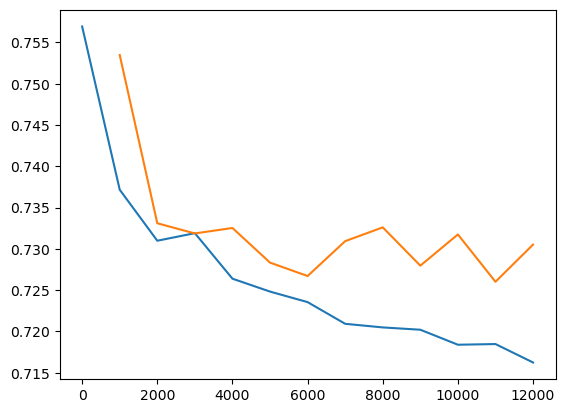

In [128]:
loss_train_bucket_means = []
for i in range(0, len(loss_train), log_every):
  loss_train_bucket_means.append(np.mean(loss_train[i:i+log_every]))

plt.plot([i*1000 for i in range(len(loss_train_bucket_means))], loss_train_bucket_means)
plt.plot([i*1000 for i in range(1, len(loss_val))], loss_val[1:])

plt.show()

# Save + Load Model

In [ ]:
# Manually save the model state at the end of a training run.
#
# Note: the best checkpoint is already saved automatically during training
# whenever val loss improves (as best_checkpoint_{run_timestamp}.pth).
# Use this cell only if you want to explicitly snapshot the *final* weights,
# which may differ from the best checkpoint if val loss rose at the end.
#
# `best_path` is set by the training loop above and always points to the
# best val checkpoint of the most recent run in this session.
final_path = os.path.join(checkpoint_dir, f'final_{run_timestamp}.pth')
torch.save(model.state_dict(), final_path)
print(f"Saved final weights → {final_path}")
print(f"Best checkpoint for this run → {best_path}")


In [142]:
# List all saved checkpoints, sorted by modification time (most recent first).
import glob

checkpoints = sorted(
    glob.glob(os.path.join(checkpoint_dir, '*.pth')),
    key=os.path.getmtime,
    reverse=True
)
print(f"Checkpoints in '{checkpoint_dir}':")
for ckpt in checkpoints:
    size_kb = os.path.getsize(ckpt) / 1024
    print(f"  {os.path.basename(ckpt):60s}  {size_kb:.0f} KB")


Checkpoints in 'saved_models':
  GOLDEN_MODEL_20260329_211846.pth                              915 KB
  checkpoint_20260329_211846_step_120000.pth                    915 KB
  best_checkpoint_20260329_211846.pth                           915 KB
  checkpoint_20260329_211846_step_090000.pth                    915 KB
  checkpoint_20260329_211846_step_060000.pth                    915 KB
  checkpoint_20260329_211846_step_030000.pth                    915 KB
  best_checkpoint_20260329_205855.pth                           572 KB
  checkpoint_20260329_205855_step_120000.pth                    572 KB
  checkpoint_20260329_205855_step_090000.pth                    572 KB
  checkpoint_20260329_205855_step_060000.pth                    572 KB
  checkpoint_20260329_205855_step_030000.pth                    572 KB
  checkpoint_20260329_194041_step_120000.pth                    572 KB
  checkpoint_20260329_194041_step_090000.pth                    572 KB
  best_checkpoint_20260329_194041.pth         

In [143]:
# Load a model checkpoint for inference or continued training.
#
# Option 1 — best checkpoint from the current session's training run:
#   PATH = best_path        (set automatically by the training loop above)
#
# Option 2 — specific checkpoint from a previous run (replace the timestamp):
#   PATH = 'saved_models/best_checkpoint_20260329_143022.pth'
#   PATH = 'saved_models/checkpoint_20260329_143022_step_120000.pth'
#
# Option 3 — most recent best checkpoint on disk (useful after a fresh kernel restart):
#   import glob, os
#   PATH = max(glob.glob('saved_models/best_checkpoint_*.pth'), key=os.path.getmtime)

PATH = 'saved_models/GOLDEN_MODEL_20260329_211846.pth'

model = MovieRecommender(
    genres_len=len(genres),
    tags_len=len(final_movie_tags),
    genome_tags_len=len(final_movie_genome_tags),
    top_movies_len=len(top_movies),
    all_years_len=len(year_to_num_movies),
    timestamp_num_bins=timestamp_num_bins,
    user_context_size=user_context_size,
    item_genre_embedding_size=item_genre_embedding_size,
    item_tag_embedding_size=item_tag_embedding_size,
    item_genome_tag_embedding_size=item_genome_tag_embedding_size,
    item_movieId_embedding_size=item_movieId_embedding_size,
    item_year_embedding_size=item_year_embedding_size,
    user_genre_embedding_size=user_genre_embedding_size,
    user_tag_embedding_size=user_tag_embedding_size,
    timestamp_feature_embedding_size=timestamp_feature_embedding_size,
    use_user_tag_tower=USE_USER_TAG_TOWER,
    use_item_tag_tower=USE_ITEM_TAG_TOWER,
    use_item_genome_tag_tower=USE_ITEM_GENOME_TAG_TOWER,
)
model.load_state_dict(torch.load(PATH, weights_only=True))
model.eval()
print(f"Loaded checkpoint: {PATH}")


Loaded checkpoint: saved_models/GOLDEN_MODEL_20260329_211846.pth


# Actually Using the Model

In [144]:
# Always set the model to eval mode before using it for inference tasks.

model.eval()

MovieRecommender(
  (item_embedding_lookup): Embedding(4462, 40, padding_idx=4461)
  (item_embedding_tower): Sequential(
    (0): Linear(in_features=40, out_features=40, bias=True)
    (1): Tanh()
  )
  (item_genre_tower): Sequential(
    (0): Linear(in_features=20, out_features=10, bias=True)
    (1): Tanh()
  )
  (item_tag_tower): Sequential(
    (0): Linear(in_features=306, out_features=15, bias=True)
    (1): Tanh()
  )
  (item_genome_tag_tower): Sequential(
    (0): Linear(in_features=1128, out_features=25, bias=True)
    (1): Tanh()
  )
  (year_embedding_lookup): Embedding(192, 10)
  (year_embedding_tower): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): Tanh()
  )
  (user_genre_tower): Sequential(
    (0): Linear(in_features=40, out_features=50, bias=True)
    (1): Tanh()
  )
  (timestamp_embedding_lookup): Embedding(1500, 10)
  (timestamp_embedding_tower): Sequential(
    (0): Linear(in_features=10, out_features=10, bias=True)
    (1): Tanh()
  

In [145]:
# for every movie, save all its embeddings
movieId_to_embedding = {}

ITEM_EMBEDDING_LOOKUP = model.item_embedding_lookup.weight
YEAR_EMBEDDING_LOOKUP = model.year_embedding_lookup.weight

for movieId in top_movies:
  movieId_to_embedding[movieId] = {}

  item_embedding = ITEM_EMBEDDING_LOOKUP[torch.tensor([item_emb_movieId_to_i[movieId]])]
  movieId_to_embedding[movieId]['MOVIEID_EMBEDDING'] = model.item_embedding_tower(item_embedding)

  year_embedding = YEAR_EMBEDDING_LOOKUP[torch.tensor([year_to_i[movieId_to_year[movieId]]])]
  movieId_to_embedding[movieId]['MOVIE_YEAR_EMBEDDING'] = model.year_embedding_tower(year_embedding)

  movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING'] = model.item_genre_tower(torch.tensor([movieId_to_genre_context[movieId]]))

  item_id_emb    = movieId_to_embedding[movieId]['MOVIEID_EMBEDDING']
  item_genre_emb = movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING']
  iteam_year_emb = movieId_to_embedding[movieId]['MOVIE_YEAR_EMBEDDING']

  item_parts = [item_genre_emb]

  if model.use_item_tag_tower:
      movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING'] = model.item_tag_tower(torch.tensor([movieId_to_tag_context[movieId]]))
      item_parts.append(movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING'])

  if model.use_item_genome_tag_tower:
      movieId_to_embedding[movieId]['MOVIE_GENOME_TAG_EMBEDDING'] = model.item_genome_tag_tower(torch.tensor([movieId_to_genome_tag_context[movieId]]))
      item_parts.append(movieId_to_embedding[movieId]['MOVIE_GENOME_TAG_EMBEDDING'])

  item_parts += [item_id_emb, iteam_year_emb]
  movieId_to_embedding[movieId]['MOVIE_EMBEDDING_COMBINED'] = torch.cat(item_parts, dim=1)


In [146]:
for emb_type in movieId_to_embedding[5952].keys():
  print(movieId_to_embedding[5952][emb_type].shape)

torch.Size([1, 40])
torch.Size([1, 10])
torch.Size([1, 10])
torch.Size([1, 15])
torch.Size([1, 25])
torch.Size([1, 100])


### Viewing Movies in 2D

In [ ]:
plt.figure(figsize=(15,15))
for movieId in top_movies[0:25]:
  i = item_emb_movieId_to_i[movieId]
  plt.scatter(ITEM_EMBEDDING_LOOKUP[i,0].data, ITEM_EMBEDDING_LOOKUP[i,1].data, s=200)
  plt.text(ITEM_EMBEDDING_LOOKUP[i,0].item(), ITEM_EMBEDDING_LOOKUP[i,1].item(), movieId_to_title[movieId][0:20], ha="center", va="center", color='black')
plt.grid('minor')

plt.show()

### Finding Most Similar Movies

In [134]:
# Compute pairwise cosine similarity between all movie combined embeddings.
#
# Previously used L2 (Euclidean) distance in a nested Python loop — O(N^2) iterations.
# This version stacks all embeddings into a matrix and does a single (N, D) x (D, N)
# matmul, which is orders of magnitude faster and uses cosine similarity instead.
#
# Cosine similarity is more appropriate here than L2 distance because the model was
# trained with a dot product objective: the embedding space is organized by angle,
# not magnitude. L2 conflates direction and scale; cosine only measures direction.
#
# Results are stored as (movieId, similarity) tuples sorted descending (most similar first).
# The movie itself is excluded from its own result list.

movie_ids = list(top_movies)

# Stack combined embeddings into a single matrix: (N, D)
emb_matrix = torch.stack([
    movieId_to_embedding[mid]['MOVIE_EMBEDDING_COMBINED'].view(-1)
    for mid in movie_ids
])

# L2-normalize each row so that matmul gives cosine similarity: (N, N)
emb_norm = torch.nn.functional.normalize(emb_matrix, dim=1)
sim_matrix = emb_norm @ emb_norm.T  # cosine similarity for all pairs

movieId_to_emb_type_to_similarities = {}
for i, movieId in enumerate(movie_ids):
    sims = sim_matrix[i]  # cosine similarity of movie i to all others
    # Sort descending; exclude self (j == i)
    sorted_indices = sims.argsort(descending=True)
    top = [
        (movie_ids[j.item()], sims[j].item())
        for j in sorted_indices
        if j.item() != i
    ][:100]
    movieId_to_emb_type_to_similarities[movieId] = {'MOVIE_EMBEDDING_COMBINED': top}


In [135]:
from IPython.display import display, Markdown

titles = [
    'Lord of the Rings: The Return of the King, The (2003)',
    'Star Wars: Episode IV - A New Hope (1977)',
    'Toy Story (1995)',
    'Saving Private Ryan (1998)',
    'Kill Bill: Vol. 1 (2003)',
    'American Pie (1999)',
    'Blair Witch Project, The (1999)',
    'Princess Mononoke (Mononoke-hime) (1997)'
]

emb_type = 'MOVIE_EMBEDDING_COMBINED'
top_n = 5

rows = []
for title in titles:
    movieId = title_to_movieId[title]
    similars = [movieId_to_title[target_id]
                for target_id, sim in movieId_to_emb_type_to_similarities[movieId][emb_type][:top_n]]
    rows.append([title] + similars)

sep_cols = '|' + '|'.join(['---'] * (top_n + 1)) + '|'
header   = '| Movie | ' + ' | '.join('Similar ' + str(i+1) for i in range(top_n)) + ' |'
lines    = [header, sep_cols] + ['| ' + ' | '.join(row) + ' |' for row in rows]
display(Markdown('\n'.join(lines)))


| Movie | Similar 1 | Similar 2 | Similar 3 | Similar 4 | Similar 5 |
|---|---|---|---|---|---|
| Lord of the Rings: The Return of the King, The (2003) | Lord of the Rings: The Two Towers, The (2002) | Lord of the Rings: The Fellowship of the Ring, The (2001) | Star Wars: Episode VI - Return of the Jedi (1983) | Star Wars: Episode V - The Empire Strikes Back (1980) | Star Wars: Episode IV - A New Hope (1977) |
| Star Wars: Episode IV - A New Hope (1977) | Star Wars: Episode V - The Empire Strikes Back (1980) | Star Wars: Episode VI - Return of the Jedi (1983) | Serenity (2005) | Batman Begins (2005) | Lord of the Rings: The Two Towers, The (2002) |
| Toy Story (1995) | Toy Story 2 (1999) | Shrek (2001) | Ratatouille (2007) | Finding Nemo (2003) | Monsters, Inc. (2001) |
| Saving Private Ryan (1998) | Warrior (2011) | Black Hawk Down (2001) | Enemy at the Gates (2001) | Blood Diamond (2006) | Braveheart (1995) |
| Kill Bill: Vol. 1 (2003) | Kill Bill: Vol. 2 (2004) | Blood Simple (1984) | Old Boy (2003) | District 9 (2009) | Sin City (2005) |
| American Pie (1999) | American Reunion (American Pie 4) (2012) | American Wedding (American Pie 3) (2003) | Hangover Part II, The (2011) | EuroTrip (2004) | Horrible Bosses 2 (2014) |
| Blair Witch Project, The (1999) | Paranormal Activity (2009) | It Comes at Night (2017) | Mama (2013) | Splice (2009) | Box, The (2009) |
| Princess Mononoke (Mononoke-hime) (1997) | Nausicaä of the Valley of the Wind (Kaze no tani no Naushika) (1984) | Laputa: Castle in the Sky (Tenkû no shiro Rapyuta) (1986) | Howl's Moving Castle (Hauru no ugoku shiro) (2004) | Your Name. (2016) | My Neighbor Totoro (Tonari no Totoro) (1988) |

### Get Recommendations for Users

In [ ]:
for movieId in user_context_movies:
    print(movieId_to_title[movieId], movieId_to_genres[movieId])

In [165]:
user_type_to_favorite_genres = {
    'Fantasy Lover': ['Fantasy'],
    'Children\'s Movie Lover': ['Children'],
    'Horror Lover': ['Horror'],
    'Sci-Fi Lover': ['Sci-Fi'],
    'Comedy Lover': ['Comedy'],
    'Romance Lover': ['Romance'],
    'War Movie Lover': ['War'],
    'Thriller Lover': ['Thriller'],
    'Crime Lover': ['Crime'],

    # profile for myself
    'Myself': ['Fantasy', 'War', 'Horror', 'Drama', 'Action']
}

user_type_to_worst_genres = {
    'Fantasy Lover': ['Horror', 'Children'],
    'Children\'s Movie Lover': ['Horror', 'Romance', 'Drama', 'Action'],
    'Horror Lover': ['Children'],
    'Sci-Fi Lover': ['Romance', 'Children'],
    'Comedy Lover': ['Children'],
    'Romance Lover': ['Children', 'Horror'],
    'War Movie Lover': ['Children'],
    'Thriller Lover': ['Children', 'Comedy'],
    'Crime Lover': ['Children', 'Fantasy', 'Romance', 'Comedy'],

    # profile for myself
    'Myself': ['Romance']
}

user_type_to_favorite_movies = {
    'Fantasy Lover': [
        'Lord of the Rings: The Fellowship of the Ring, The (2001)',
        'Princess Bride, The (1987)',
        'Willow (1988)',
        'Excalibur (1981)',
        'Labyrinth (1986)',
        'Legend (1985)',
        'Dark Crystal, The (1982)',
        'Fantastic Beasts and Where to Find Them (2016)',
        'Hobbit: An Unexpected Journey, The (2012)',
    ],
    'Children\'s Movie Lover': [
        'Toy Story 2 (1999)',
        'Finding Nemo (2003)',
        'Monsters, Inc. (2001)',
        'Toy Story (1995)',
        'Lion King, The (1994)',
        'Shrek (2001)',
        'Babe (1995)',
        "Charlotte's Web (1973)",
        'Road to El Dorado, The (2000)',
    ],
    'Horror Lover': [
        'Blair Witch Project, The (1999)',
        'Silence of the Lambs, The (1991)',
        'Shining, The (1980)',
        "Rosemary's Baby (1968)",
        'Halloween (1978)',
        'Get Out (2017)',
        'Psycho (1960)',
        'Birds, The (1963)',
        'Poltergeist (1982)',
        'Nightmare on Elm Street, A (1984)',
    ],
    'Sci-Fi Lover': [
        'Matrix, The (1999)',
        'Terminator, The (1984)',
        '2001: A Space Odyssey (1968)',
        'Blade Runner (1982)',
        'Arrival (2016)',
        'Interstellar (2014)',
        'Blade Runner 2049 (2017)',
        'Contact (1997)',
        'Ghost in the Shell (Kôkaku kidôtai) (1995)',
        'Terminator 2: Judgment Day (1991)',
        'Star Wars: Episode IV - A New Hope (1977)',
        'Independence Day (a.k.a. ID4) (1996)',
    ],
    'Comedy Lover': [
        'American Pie (1999)',
        'Dumb & Dumber (Dumb and Dumber) (1994)',
        'Big Lebowski, The (1998)',
        'Monty Python and the Holy Grail (1975)',
        'Airplane! (1980)',
        'Spaceballs (1987)',
        'Ferris Bueller\'s Day Off (1986)',
        'Clerks (1994)',
        'Office Space (1999)',
        "Monty Python's Life of Brian (1979)",
    ],
    'Romance Lover': [
        'Shakespeare in Love (1998)',
        'Sense and Sensibility (1995)',
        'When Harry Met Sally... (1989)',
        'Sleepless in Seattle (1993)',
        'Notting Hill (1999)',
        'Four Weddings and a Funeral (1994)',
        'Annie Hall (1977)',
        'Casablanca (1942)',
        'Jerry Maguire (1996)',
    ],
    'War Movie Lover': [
        'Saving Private Ryan (1998)',
        'Apocalypse Now (1979)',
        'Full Metal Jacket (1987)',
        'Platoon (1986)',
        'Bridge on the River Kwai, The (1957)',
        'Glory (1989)',
        'Deer Hunter, The (1978)',
        'Paths of Glory (1957)',
        'Downfall (Untergang, Der) (2004)',
        '1917 (2019)',
        'Enemy at the Gates (2001)',
    ],
    'Thriller Lover': [
        'Seven (a.k.a. Se7en) (1995)',
        'Memento (2000)',
        'Usual Suspects, The (1995)',
        'Zodiac (2007)',
        'Fight Club (1999)',
        'Game, The (1997)',
        'Vertigo (1958)',
    ],
    'Crime Lover': [
        'Godfather, The (1972)',
        'Goodfellas (1990)',
        'Reservoir Dogs (1992)',
        'L.A. Confidential (1997)',
        'Departed, The (2006)',
        'Scarface (1983)',
        'Casino (1995)',
    ],

    # profile for myself
    'Myself': [
        'Lord of the Rings: The Fellowship of the Ring, The (2001)',
        'Lord of the Rings: The Return of the King, The (2003)',
        '300 (2007)',
        'Saving Private Ryan (1998)',
        'Kill Bill: Vol. 1 (2003)',
        'Gladiator (2000)',
        'Braveheart (1995)'
    ]
}

# Movies the user has seen and disliked — assigned a negative debiased rating to
# actively pull the user embedding away from these genres.
user_type_to_disliked_movies = {
    'Fantasy Lover': [
        'Get Out (2017)',                                    # Horror
        'Poltergeist (1982)',                               # Horror|Thriller
        'Nightmare on Elm Street, A (1984)',                # Horror|Thriller
        'Coco (2017)',                                      # Children
        'Iron Giant, The (1999)',                           # Children
    ],
    'Children\'s Movie Lover': [
        'Get Out (2017)',                                   # Horror
        'Nightmare on Elm Street, A (1984)',                # Horror|Thriller
        'Casablanca (1942)',                                # Drama|Romance
        'Jerry Maguire (1996)',                             # Drama|Romance
        "Schindler's List (1993)",                          # Drama|War
        'Die Hard (1988)',                                  # Action|Crime|Thriller
        'Terminator 2: Judgment Day (1991)',                # Action|Sci-Fi
        'Predator (1987)',                                  # Action|Sci-Fi|Thriller
        'RoboCop (1987)',                                   # Action|Crime|Drama|Sci-Fi|Thriller
        'First Blood (Rambo: First Blood) (1982)',          # Action|Adventure|Drama|Thriller
        'Fast & Furious 6 (Fast and the Furious 6, The) (2013)',  # Action|Crime|Thriller
        'Furious 7 (2015)',                                 # Action|Crime|Thriller
    ],
    'Horror Lover': [
        'Coco (2017)',                                      # Children
        'My Neighbor Totoro (Tonari no Totoro) (1988)',     # Children
        'Iron Giant, The (1999)',                           # Children
    ],
    'Sci-Fi Lover': [
        'Casablanca (1942)',                                # Drama|Romance
        'Jerry Maguire (1996)',                             # Drama|Romance
        'Coco (2017)',                                      # Children
        'My Neighbor Totoro (Tonari no Totoro) (1988)',     # Children
    ],
    'Comedy Lover': [
        'Coco (2017)',                                      # Children
        'My Neighbor Totoro (Tonari no Totoro) (1988)',     # Children
        'Iron Giant, The (1999)',                           # Children
    ],
    'Romance Lover': [
        'Get Out (2017)',                                   # Horror
        'Poltergeist (1982)',                               # Horror|Thriller
        'Coco (2017)',                                      # Children
        'My Neighbor Totoro (Tonari no Totoro) (1988)',     # Children
    ],
    'War Movie Lover': [
        'Coco (2017)',                                      # Children
        'My Neighbor Totoro (Tonari no Totoro) (1988)',     # Children
        'Iron Giant, The (1999)',                           # Children
        'Lord of the Rings: The Fellowship of the Ring, The (2001)',  # Adventure|Fantasy
        'Avengers, The (2012)',                             # Action|Adventure|Sci-Fi
        'Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981)',  # Action|Adventure
    ],
    'Thriller Lover': [
        'Finding Nemo (2003)',                              # Children
        'My Neighbor Totoro (Tonari no Totoro) (1988)',     # Children
        'Ace Ventura: Pet Detective (1994)',                # Comedy
        'Mrs. Doubtfire (1993)',                            # Comedy|Drama
    ],
    'Crime Lover': [
        'Finding Nemo (2003)',                              # Children
        'My Neighbor Totoro (Tonari no Totoro) (1988)',     # Children
        'Lord of the Rings: The Fellowship of the Ring, The (2001)',  # Adventure|Fantasy
        'Casablanca (1942)',                                # Drama|Romance
        'Pretty Woman (1990)',                              # Comedy|Romance
    ],

    # profile for myself
    'Myself': []
}

value_for_favorite_genre_avg_rating = float(4.0)   # de-biased ratings max ~4.0 in training data
value_for_disliked_genre_avg_rating  = float(-2.0)
value_for_favorite_movie_rating      = float(2.0)   # debiased rating for seed movies (~5-star from a user with mean ~3.0)
value_for_disliked_movie_rating      = float(-2.0)  # debiased rating for disliked movies (~1-star from a user with mean ~3.0)

user_to_inference_context         = {}  # genre context vector (2*len(genres)-dim)
user_to_inference_history         = {}  # watch history: list of (emb_idx, movieId) tuples
user_to_inference_history_ratings = {}  # debiased ratings for each seed movie, parallel to history
user_to_inference_tag_context     = {}  # tag profile: avg tag vector over seed movies

for user_type in user_type_to_favorite_genres.keys():
    inference_user_context = [0.0] * user_context_size

    # First half: avg rating per genre
    for genre in user_type_to_favorite_genres[user_type]:
        inference_user_context[user_context_genre_avg_rating_to_i[genre]] = value_for_favorite_genre_avg_rating
    for genre in user_type_to_worst_genres[user_type]:
        inference_user_context[user_context_genre_avg_rating_to_i[genre]] = value_for_disliked_genre_avg_rating

    # Second half: watch count fraction per genre (equal split among favorite genres)
    num_fav_genres = len(user_type_to_favorite_genres[user_type])
    for genre in user_type_to_favorite_genres[user_type]:
        inference_user_context[user_context_genre_watch_count_to_i[genre]] = float(1.0 / num_fav_genres)

    user_to_inference_context[user_type] = inference_user_context

    # Watch history: liked movies (positive rating) + disliked movies (negative rating)
    # Only include movies that exist in the item embedding lookup
    liked_history = [
        (item_emb_movieId_to_i[title_to_movieId[title]], title_to_movieId[title])
        for title in user_type_to_favorite_movies[user_type]
        if title in title_to_movieId and title_to_movieId[title] in item_emb_movieId_to_i
    ]
    disliked_history = [
        (item_emb_movieId_to_i[title_to_movieId[title]], title_to_movieId[title])
        for title in user_type_to_disliked_movies[user_type]
        if title in title_to_movieId and title_to_movieId[title] in item_emb_movieId_to_i
    ]

    history = liked_history + disliked_history
    ratings = (
        [value_for_favorite_movie_rating] * len(liked_history) +
        [value_for_disliked_movie_rating] * len(disliked_history)
    )

    user_to_inference_history[user_type] = history
    user_to_inference_history_ratings[user_type] = ratings

    # Tag profile: average the tag vectors of liked seed movies only
    tag_context = [0.0] * len(final_movie_tags)
    num_movies = 0
    for title in user_type_to_favorite_movies[user_type]:
        if title not in title_to_movieId:
            continue
        movieId = title_to_movieId[title]
        if movieId in movieId_to_tag_context:
            for j, val in enumerate(movieId_to_tag_context[movieId]):
                tag_context[j] += val
            num_movies += 1
    if num_movies > 0:
        tag_context = [v / num_movies for v in tag_context]
    user_to_inference_tag_context[user_type] = tag_context


In [166]:
model.eval()
user_to_top_recs = {}

for user_type in user_to_inference_context.keys():
    with torch.no_grad():
        # Genre context
        X_inference = torch.tensor([user_to_inference_context[user_type]])
        genre_embedding_inference = model.user_genre_tower(X_inference)

        # Watch history: avg pool of favorite movies' embeddings
        history = user_to_inference_history[user_type]
        if len(history) > 0:
            hist_ids     = torch.tensor([h[0] for h in history], dtype=torch.long).unsqueeze(0)                    # (1, hist_len)
            hist_weights = torch.tensor([user_to_inference_history_ratings[user_type]], dtype=torch.float)  # (1, hist_len)
            hist_embs    = model.item_embedding_lookup(hist_ids)                                   # (1, hist_len, emb_dim)
            weight_sum   = hist_weights.unsqueeze(-1).abs().sum(dim=1).clamp(min=1e-6)
            history_emb  = (hist_embs * hist_weights.unsqueeze(-1)).sum(dim=1) / weight_sum        # (1, emb_dim)
        else:
            history_emb = torch.zeros(1, model.item_embedding_lookup.embedding_dim)

        # Timestamp: use most recent timestamp from training data
        timestamp_inference = torch.bucketize(torch.tensor([df_ratings['timestamp'].max()]), timestamp_bins, right=False)
        timestamp_embedding = model.timestamp_embedding_tower(model.timestamp_embedding_lookup(timestamp_inference))

        # Combine user side
        if model.use_user_tag_tower:
            X_tag_inference = torch.tensor([user_to_inference_tag_context[user_type]])
            tag_embedding_inference = model.user_tag_tower(X_tag_inference)
            user_and_timestamp_combined_embedding = torch.cat((history_emb, genre_embedding_inference, tag_embedding_inference, timestamp_embedding), dim=1)
        else:
            user_and_timestamp_combined_embedding = torch.cat((history_emb, genre_embedding_inference, timestamp_embedding), dim=1)

        movieId_to_pred_score = {}
        for movieId in top_movies:
            item_embedding_combined_inference = movieId_to_embedding[movieId]['MOVIE_EMBEDDING_COMBINED']
            preds = torch.einsum('ij, ij -> i', user_and_timestamp_combined_embedding, item_embedding_combined_inference)
            movieId_to_pred_score[movieId] = preds

    top_recs = []
    show_top_recs = True
    for movieId, pred_score in list(sorted(movieId_to_pred_score.items(), key=lambda item: item[1], reverse=show_top_recs)):
        if len(top_recs) >= 10: break
        if (movieId_to_title[movieId] not in user_type_to_favorite_movies[user_type] and
                movieId_to_title[movieId] not in user_type_to_disliked_movies[user_type]):
            top_recs.append(movieId)
    user_to_top_recs[user_type] = top_recs


In [167]:
from IPython.display import display, Markdown
from itertools import zip_longest

for user_type in user_to_top_recs.keys():
    liked_genres    = ', '.join(user_type_to_favorite_genres[user_type])
    disliked_genres = ', '.join(user_type_to_worst_genres[user_type])
    liked_movies    = user_type_to_favorite_movies[user_type]
    disliked_movies = user_type_to_disliked_movies[user_type]
    recs            = [movieId_to_title[m] for m in user_to_top_recs[user_type]]

    heading = f'### {user_type}  |  Likes: {liked_genres}  |  Dislikes: {disliked_genres}'
    header  = '| Liked Movies | Disliked Movies | Recommendations |'
    sep     = '|---|---|---|'
    rows = [
        f'| {a} | {b} | {c} |'
        for a, b, c in zip_longest(liked_movies, disliked_movies, recs, fillvalue='')
    ]
    display(Markdown('\n'.join([heading, header, sep] + rows)))


### Fantasy Lover  |  Likes: Fantasy  |  Dislikes: Horror, Children
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Lord of the Rings: The Fellowship of the Ring, The (2001) | Get Out (2017) | Dark City (1998) |
| Princess Bride, The (1987) | Poltergeist (1982) | Lord of the Rings: The Two Towers, The (2002) |
| Willow (1988) | Nightmare on Elm Street, A (1984) | Everything Everywhere All at Once (2022) |
| Excalibur (1981) | Coco (2017) | Brazil (1985) |
| Labyrinth (1986) | Iron Giant, The (1999) | What We Do in the Shadows (2014) |
| Legend (1985) |  | Donnie Darko (2001) |
| Dark Crystal, The (1982) |  | Lord of the Rings: The Return of the King, The (2003) |
| Fantastic Beasts and Where to Find Them (2016) |  | Lost Highway (1997) |
| Hobbit: An Unexpected Journey, The (2012) |  | Delicatessen (1991) |
|  |  | After Hours (1985) |

### Children's Movie Lover  |  Likes: Children  |  Dislikes: Horror, Romance, Drama, Action
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Toy Story 2 (1999) | Get Out (2017) | Despicable Me (2010) |
| Finding Nemo (2003) | Nightmare on Elm Street, A (1984) | Despicable Me 2 (2013) |
| Monsters, Inc. (2001) | Casablanca (1942) | Ice Age 2: The Meltdown (2006) |
| Toy Story (1995) | Jerry Maguire (1996) | Shrek 2 (2004) |
| Lion King, The (1994) | Schindler's List (1993) | Ice Age: Dawn of the Dinosaurs (2009) |
| Shrek (2001) | Die Hard (1988) | Ice Age (2002) |
| Babe (1995) | Terminator 2: Judgment Day (1991) | Madagascar (2005) |
| Charlotte's Web (1973) | Predator (1987) | Bug's Life, A (1998) |
| Road to El Dorado, The (2000) | RoboCop (1987) | Shrek the Third (2007) |
|  | First Blood (Rambo: First Blood) (1982) | Hotel Transylvania (2012) |
|  | Fast & Furious 6 (Fast and the Furious 6, The) (2013) |  |
|  | Furious 7 (2015) |  |

### Horror Lover  |  Likes: Horror  |  Dislikes: Children
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Blair Witch Project, The (1999) | Coco (2017) | Scream (1996) |
| Silence of the Lambs, The (1991) | My Neighbor Totoro (Tonari no Totoro) (1988) | Friday the 13th (1980) |
| Shining, The (1980) | Iron Giant, The (1999) | Friday the 13th Part 2 (1981) |
| Rosemary's Baby (1968) |  | Freddy vs. Jason (2003) |
| Halloween (1978) |  | Hills Have Eyes, The (2006) |
| Get Out (2017) |  | Halloween II (1981) |
| Psycho (1960) |  | Saw II (2005) |
| Birds, The (1963) |  | Hostel (2005) |
| Poltergeist (1982) |  | Halloween (2007) |
| Nightmare on Elm Street, A (1984) |  | You're Next (2011) |

### Sci-Fi Lover  |  Likes: Sci-Fi  |  Dislikes: Romance, Children
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Matrix, The (1999) | Casablanca (1942) | Dark City (1998) |
| Terminator, The (1984) | Jerry Maguire (1996) | Twin Peaks: Fire Walk with Me (1992) |
| 2001: A Space Odyssey (1968) | Coco (2017) | Videodrome (1983) |
| Blade Runner (1982) | My Neighbor Totoro (Tonari no Totoro) (1988) | Dead Man (1995) |
| Arrival (2016) |  | Lost Highway (1997) |
| Interstellar (2014) |  | Cemetery Man (Dellamorte Dellamore) (1994) |
| Blade Runner 2049 (2017) |  | Naked Lunch (1991) |
| Contact (1997) |  | They Live (1988) |
| Ghost in the Shell (Kôkaku kidôtai) (1995) |  | Dogtooth (Kynodontas) (2009) |
| Terminator 2: Judgment Day (1991) |  | Day of the Dead (1985) |
| Star Wars: Episode IV - A New Hope (1977) |  |  |
| Independence Day (a.k.a. ID4) (1996) |  |  |

### Comedy Lover  |  Likes: Comedy  |  Dislikes: Children
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| American Pie (1999) | Coco (2017) | Anchorman: The Legend of Ron Burgundy (2004) |
| Dumb & Dumber (Dumb and Dumber) (1994) | My Neighbor Totoro (Tonari no Totoro) (1988) | Wayne's World (1992) |
| Big Lebowski, The (1998) | Iron Giant, The (1999) | 21 Jump Street (2012) |
| Monty Python and the Holy Grail (1975) |  | Talladega Nights: The Ballad of Ricky Bobby (2006) |
| Airplane! (1980) |  | Old School (2003) |
| Spaceballs (1987) |  | Zoolander (2001) |
| Ferris Bueller's Day Off (1986) |  | Step Brothers (2008) |
| Clerks (1994) |  | Harold and Kumar Go to White Castle (2004) |
| Office Space (1999) |  | Superbad (2007) |
| Monty Python's Life of Brian (1979) |  | There's Something About Mary (1998) |

### Romance Lover  |  Likes: Romance  |  Dislikes: Children, Horror
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Shakespeare in Love (1998) | Get Out (2017) | Twilight Saga: Breaking Dawn - Part 2, The (2012) |
| Sense and Sensibility (1995) | Poltergeist (1982) | Pretty Woman (1990) |
| When Harry Met Sally... (1989) | Coco (2017) | Coyote Ugly (2000) |
| Sleepless in Seattle (1993) | My Neighbor Totoro (Tonari no Totoro) (1988) | Twilight Saga: Breaking Dawn - Part 1, The (2011) |
| Notting Hill (1999) |  | Twilight Saga: New Moon, The (2009) |
| Four Weddings and a Funeral (1994) |  | Twilight Saga: Eclipse, The (2010) |
| Annie Hall (1977) |  | Divergent (2014) |
| Casablanca (1942) |  | Dirty Dancing (1987) |
| Jerry Maguire (1996) |  | Sweet Home Alabama (2002) |
|  |  | Twilight (2008) |

### War Movie Lover  |  Likes: War  |  Dislikes: Children
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Saving Private Ryan (1998) | Coco (2017) | Band of Brothers (2001) |
| Apocalypse Now (1979) | My Neighbor Totoro (Tonari no Totoro) (1988) | Star Wars: Episode V - The Empire Strikes Back (1980) |
| Full Metal Jacket (1987) | Iron Giant, The (1999) | Dark Knight, The (2008) |
| Platoon (1986) | Lord of the Rings: The Fellowship of the Ring, The (2001) | Star Wars: Episode IV - A New Hope (1977) |
| Bridge on the River Kwai, The (1957) | Avengers, The (2012) | Braveheart (1995) |
| Glory (1989) | Raiders of the Lost Ark (Indiana Jones and the Raiders of the Lost Ark) (1981) | Shawshank Redemption, The (1994) |
| Deer Hunter, The (1978) |  | Batman Begins (2005) |
| Paths of Glory (1957) |  | Iron Man (2008) |
| Downfall (Untergang, Der) (2004) |  | Dark Knight Rises, The (2012) |
| 1917 (2019) |  | Star Wars: Episode VI - Return of the Jedi (1983) |
| Enemy at the Gates (2001) |  |  |

### Thriller Lover  |  Likes: Thriller  |  Dislikes: Children, Comedy
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Seven (a.k.a. Se7en) (1995) | Finding Nemo (2003) | Day After Tomorrow, The (2004) |
| Memento (2000) | My Neighbor Totoro (Tonari no Totoro) (1988) | 2012 (2009) |
| Usual Suspects, The (1995) | Ace Ventura: Pet Detective (1994) | Armageddon (1998) |
| Zodiac (2007) | Mrs. Doubtfire (1993) | Olympus Has Fallen (2013) |
| Fight Club (1999) |  | London Has Fallen (2016) |
| Game, The (1997) |  | Next (2007) |
| Vertigo (1958) |  | Knowing (2009) |
|  |  | San Andreas (2015) |
|  |  | Independence Day (a.k.a. ID4) (1996) |
|  |  | Deep Impact (1998) |

### Crime Lover  |  Likes: Crime  |  Dislikes: Children, Fantasy, Romance, Comedy
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Godfather, The (1972) | Finding Nemo (2003) | Big Lebowski, The (1998) |
| Goodfellas (1990) | My Neighbor Totoro (Tonari no Totoro) (1988) | Pulp Fiction (1994) |
| Reservoir Dogs (1992) | Lord of the Rings: The Fellowship of the Ring, The (2001) | South Park: Bigger, Longer and Uncut (1999) |
| L.A. Confidential (1997) | Casablanca (1942) | Apocalypse Now (1979) |
| Departed, The (2006) | Pretty Woman (1990) | Full Metal Jacket (1987) |
| Scarface (1983) |  | Borat: Cultural Learnings of America for Make Benefit Glorious Nation of Kazakhstan (2006) |
| Casino (1995) |  | Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964) |
|  |  | Fear and Loathing in Las Vegas (1998) |
|  |  | Hard-Boiled (Lat sau san taam) (1992) |
|  |  | This Is Spinal Tap (1984) |

### Myself  |  Likes: Fantasy, War, Horror, Drama, Action  |  Dislikes: Romance
| Liked Movies | Disliked Movies | Recommendations |
|---|---|---|
| Lord of the Rings: The Fellowship of the Ring, The (2001) |  | Rogue One: A Star Wars Story (2016) |
| Lord of the Rings: The Return of the King, The (2003) |  | Platoon (1986) |
| 300 (2007) |  | Dunkirk (2017) |
| Saving Private Ryan (1998) |  | Raging Bull (1980) |
| Kill Bill: Vol. 1 (2003) |  | Dark Knight Rises, The (2012) |
| Gladiator (2000) |  | Dark Knight, The (2008) |
| Braveheart (1995) |  | Blood Diamond (2006) |
|  |  | Beasts of No Nation (2015) |
|  |  | The Revenant (2015) |
|  |  | Last Samurai, The (2003) |

In [150]:
# sanity check - make sure we aren't just recommending the higest rated movies
# NOTE: this is an extremely common problem in rec systems as the model learns
# to play it safe and just recommend what almost is highly rated.
for movieId, avg_rating in sorted(movieId_to_avg_rating.items(), key=lambda item: item[1], reverse=True)[0:10]:
  print(movieId_to_title[movieId], avg_rating)

Planet Earth II (2016) 4.451739343459089
Planet Earth (2006) 4.448092868988391
Band of Brothers (2001) 4.423985890652557
Shawshank Redemption, The (1994) 4.416792045528881
Parasite (2019) 4.3299459633841435
Godfather, The (1972) 4.32660258119567
Blue Planet II (2017) 4.312943962115233
Twin Peaks (1989) 4.302561837455831
Godfather: Part II, The (1974) 4.269509847475196
Usual Suspects, The (1995) 4.267865227113715


In [154]:
# Finding the 'most representative' movies for a specfic GENRE
genre = 'Horror'
genre_context = [0.0] * len(genres)
genre_context[genre_to_i[genre]] = float(1.0)
genre_context_emb = model.item_genre_tower(torch.tensor([genre_context])).view(-1)

movieId_to_sim = {}
for movieId in top_movies:
    movie_emb = movieId_to_embedding[movieId]['MOVIE_GENRE_EMBEDDING'].view(-1)
    sim = torch.nn.functional.cosine_similarity(genre_context_emb.unsqueeze(0), movie_emb.unsqueeze(0))
    movieId_to_sim[movieId] = sim.item()

for movieId, sim in sorted(movieId_to_sim.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'{sim:.4f}  {movieId_to_title[movieId]}')


1.0000  Baby-Sitters Club, The (1995)
0.9894  Mighty Morphin Power Rangers: The Movie (1995)
0.9888  Small Soldiers (1998)
0.9869  Alien³ (a.k.a. Alien 3) (1992)
0.9869  Thing, The (1982)
0.9869  Deep Blue Sea (1999)
0.9869  Resident Evil (2002)
0.9869  Lawnmower Man, The (1992)
0.9869  AVP: Alien vs. Predator (2004)
0.9869  Resident Evil: Apocalypse (2004)


In [152]:
# Finding the 'most representative' movies for a specfic TAG
# NOTE: requires use_item_tag_tower=True — skip this cell when the item tag tower is disabled.
assert model.use_item_tag_tower, "Item tag tower is disabled (USE_ITEM_TAG_TOWER=False); this cell requires it."

# tags = ['horror', 'gore', 'torture']
tags = ['martial arts']

# Normalize tag weights to sum to 1.0 — matches the distribution the tower was trained on
tag_context = [0.0] * len(final_movie_tags)
for tag in tags:
    tag_context[tag_to_i[tag]] = 1.0 / len(tags)
tag_context_emb = model.item_tag_tower(torch.tensor([tag_context])).view(-1)

movieId_to_sim = {}
for movieId in top_movies:
    movie_emb = movieId_to_embedding[movieId]['MOVIE_TAG_EMBEDDING'].view(-1)
    sim = torch.nn.functional.cosine_similarity(tag_context_emb.unsqueeze(0), movie_emb.unsqueeze(0))
    movieId_to_sim[movieId] = sim.item()

for movieId, sim in list(sorted(movieId_to_sim.items(), key=lambda item: item[1], reverse=True))[:10]:
    print(f'{sim:.4f}  {movieId_to_title[movieId]}')

1.0000  Mr. Nice Guy (Yat goh ho yan) (1997)
1.0000  Bloodsport 2 (a.k.a. Bloodsport II: The Next Kumite) (1996)
0.9985  Drunken Master (Jui kuen) (1978)
0.9941  First Strike (Police Story 4: First Strike) (Ging chaat goo si 4: Ji gaan daan yam mo) (1996)
0.9941  Once Upon a Time in China (Wong Fei Hung) (1991)
0.9852  Legend of Drunken Master, The (Jui kuen II) (1994)
0.9830  Jet Li's Fearless (Huo Yuan Jia) (2006)
0.9803  Iron Monkey (Siu nin Wong Fei-hung ji: Tit Ma Lau) (1993)
0.9801  Forbidden Kingdom, The (2008)
0.9763  Mortal Kombat (1995)


In [153]:
# Finding the 'most representative' movies for a specfic GENOME-TAG
# NOTE: requires use_item_genome_tag_tower=True — skip this cell when the item genome tag tower is disabled.
assert model.use_item_genome_tag_tower, "Genome tag tower is disabled (USE_ITEM_GENOME_TAG_TOWER=False); this cell requires it."

genome_tags = ['horror', 'gore', 'torture']
# genome_tags = ['dystopia', 'artificial intelligence', 'martial arts']

# genome_tag_to_i keys are integer tagIds; build a name->index lookup via genome_tag_id_to_tag_name
genome_tag_name_to_i = {name: genome_tag_to_i[tagId]
                        for tagId, name in genome_tag_id_to_tag_name.items()
                        if tagId in genome_tag_to_i}

# Step 1: find top-K movies by raw genome score for the target tags — use as query anchors
# (avoids out-of-distribution artificial query vectors; keeps everything in the learned embedding space)
K = 5
raw_scores = {}
for movieId in top_movies:
    raw_scores[movieId] = sum(movieId_to_genome_tag_context[movieId][genome_tag_name_to_i[tag]]
                              for tag in genome_tags)
anchor_ids = sorted(raw_scores, key=raw_scores.get, reverse=True)[:K]
print(f"Query anchors (top-{K} by raw genome score):")
for m in anchor_ids:
    print(f"  {movieId_to_title[m]}  (score: {raw_scores[m]:.3f})")
print()

# Step 2: average their learned genome tag embeddings → centroid query
query_emb = torch.stack([movieId_to_embedding[m]['MOVIE_GENOME_TAG_EMBEDDING'].view(-1)
                         for m in anchor_ids]).mean(dim=0)

# Step 3: find movies closest to the centroid in learned embedding space
movieId_to_sim = {}
for movieId in top_movies:
    movie_emb = movieId_to_embedding[movieId]['MOVIE_GENOME_TAG_EMBEDDING'].view(-1)
    sim = torch.nn.functional.cosine_similarity(query_emb.unsqueeze(0), movie_emb.unsqueeze(0))
    movieId_to_sim[movieId] = sim.item()

for movieId, sim in sorted(movieId_to_sim.items(), key=lambda x: x[1], reverse=True)[:10]:
    print(f'{sim:.4f}  {movieId_to_title[movieId]}')

Query anchors (top-5 by raw genome score):
  Hostel (2005)  (score: 2.887)
  Saw IV (2007)  (score: 2.865)
  Saw III (2006)  (score: 2.847)
  Saw V (2008)  (score: 2.759)
  Martyrs (2008)  (score: 2.758)

0.9975  Saw VI (2009)
0.9970  Saw IV (2007)
0.9965  Saw III (2006)
0.9958  Saw V (2008)
0.9950  Hostel (2005)
0.9947  Saw VII 3D - The Final Chapter (2010)
0.9946  Saw II (2005)
0.9931  Hostel: Part II (2007)
0.9909  Saw (2004)
0.9906  Hills Have Eyes, The (2006)
